<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_3_%D0%9C%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%B5_%D0%BD%D0%B0%D0%B2%D1%87%D0%B0%D0%BD%D0%BD%D1%8F_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 3. Машинне навчання. Лінійна регресія. Чуркін ФІТ 3-15 номер 15

Був присутній на парі

Завдання 1. Завантажити Diabetes Dataset Цей датасет містить 10 фізіологічних змінних (вік, стать, індекс маси тіла, артеріальний тиск та інші) та одну цільову змінну, яка представляє прогрес діабету через рік після вихідних даних.

Перші 5 рядків:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Пропущені значення:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Кількість дублікатів: 0

Унікальні значення статі:
[ 0.05068012 -0.04464164]

Типи даних:
age       float64
sex   

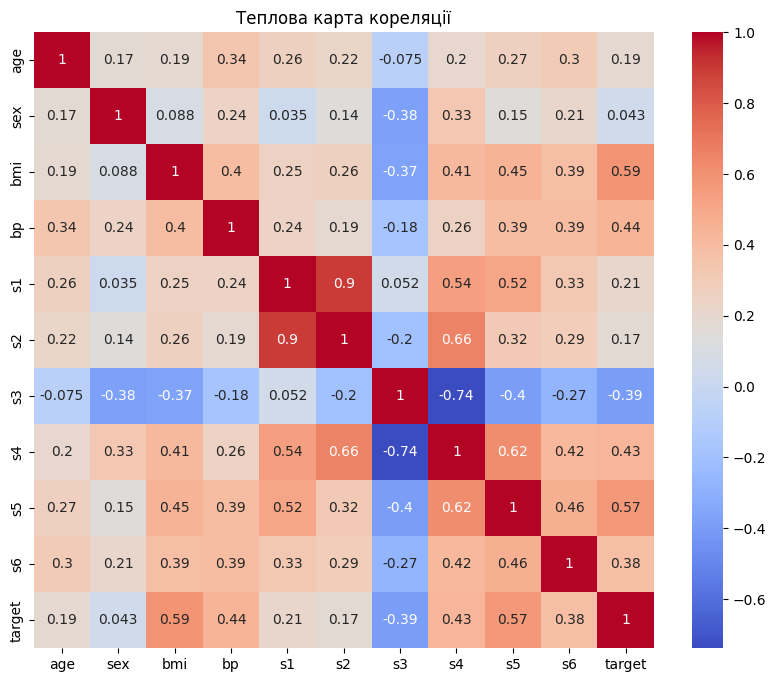


Найбільш корелюючі ознаки: ['bmi', 's5', 'bp', 's4', 's6']

Лінійна регресія:
R2: 0.4526878768819975
MSE: 2899.7426820819783

Random Forest:
R2: 0.4199245932360355
MSE: 3073.3275306179776


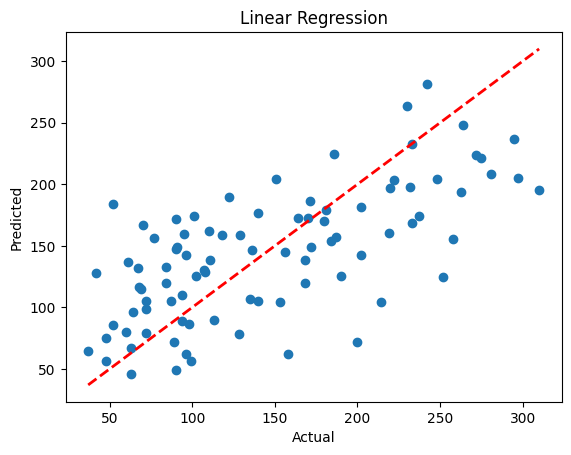

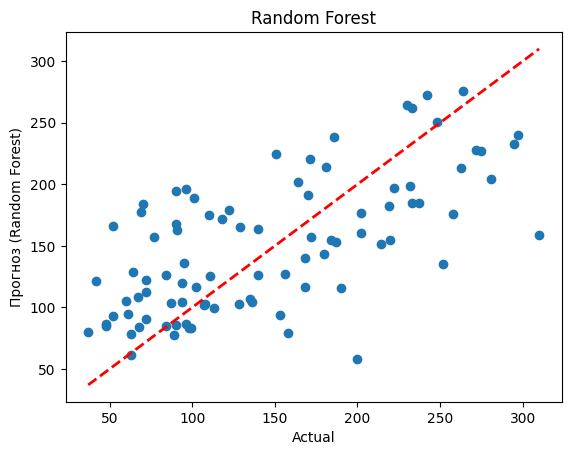


Порівняння значень:
   Actual  Linear_Predicted  RF_Predicted
0   219.0        160.079344       182.250
1    70.0        167.202676       184.255
2   202.0        181.557882       176.655
3   230.0        263.634780       264.410
4   111.0        138.707761       125.680


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target


# 1.Вивести перших 5 рядків.
print("Перші 5 рядків:")
print(df.head())


# 2.Перевірити наявність пропусків. У разі виявлення замінити на середнє значення.
print("\nПропущені значення:")
print(df.isnull().sum())

df.fillna(df.mean(), inplace=True)

# 3.Перевірити наявність дублікатів, при виявленні – видалити.
print("\nКількість дублікатів:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


# 4.Замінити бінарні ознаки. У стовпчику «стать» спочатку перевірте унікальні значення.
print("\nУнікальні значення статі:")
print(df["sex"].unique())

# 5.Перевірити тип даних. При необхідності замінити тип даних на числовий.
print("\nТипи даних:")
print(df.dtypes)

# 6.Обчислити кореляцію між прогресом діабету і іншмим ознаками. Розташувати в порядку спадання. Побудувати теплову карту кореляції.
corr = df.corr()
target_corr = corr["target"].sort_values(ascending=False)
print("\nКореляція з target:")
print(target_corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Теплова карта кореляції")
plt.show()

# 7.Масштабувати ознаки.
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 8.Поділити дані на тренувальну і тестову вибірки.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 9.Побудувати модель лінійной регресії і RandomForest регресії на основі більш корелюючих ознак (підібрати оптимальне число).
top_features = target_corr.index[1:6]
print("\nНайбільш корелюючі ознаки:", list(top_features))

X_top = df[top_features]
X_top_scaled = scaler.fit_transform(X_top)

X_train, X_test, y_train, y_test = train_test_split(
    X_top_scaled, y, test_size=0.2, random_state=42
)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# 10.Вивести коефіцієнт детермінації і середньоквадратичну помилку.
print("\nЛінійна регресія:")
print("R2:", r2_score(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))

print("\nRandom Forest:")
print("R2:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

# 11.Побудувати графіки.
plt.figure()

plt.scatter(y_test, y_pred_lin)

min_val = min(y_test.min(), y_pred_lin.min())
max_val = max(y_test.max(), y_pred_lin.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    linestyle="--",
    zorder=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")

plt.show()
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Прогноз (Random Forest)")
plt.title("Random Forest")


min_val = min(y_test.min(), y_pred_lin.min())
max_val = max(y_test.max(), y_pred_lin.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    linestyle="--",
    zorder=2
)
plt.show()
# 12.Вивести справжні і прогнозовані значення.
results = pd.DataFrame({
    "Actual": y_test.values,
    "Linear_Predicted": y_pred_lin,
    "RF_Predicted": y_pred_rf
})

print("\nПорівняння значень:")
print(results.head())

Висновок:
У ході виконання завдання було проведено аналіз набору даних та побудовано регресійну модель для прогнозування цільової змінної.

Було здійснено попередню обробку даних, перевірено наявність пропусків, виконано поділ вибірки на тренувальну та тестову частини. Після навчання моделі проведено оцінювання її якості за допомогою метрик R² та MSE.
Отримані результати показали, що модель здатна пояснювати значну частину варіації цільової змінної. Значення коефіцієнта детермінації R² свідчить про адекватність побудованої моделі, а показник середньоквадратичної помилки MSE дозволяє оцінити середній рівень відхилення прогнозів від реальних значень.

Побудований графік порівняння фактичних і прогнозованих значень продемонстрував, що більшість точок розташовані поблизу лінії ідеального передбачення, що підтверджує коректність роботи моделі.

Завдання 2. Завантажити датасет California Housing Dataset, що містить інформацію про житло в Каліфорнії. Вивести перших 5 рядків.

Перші 5 рядків:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  fl

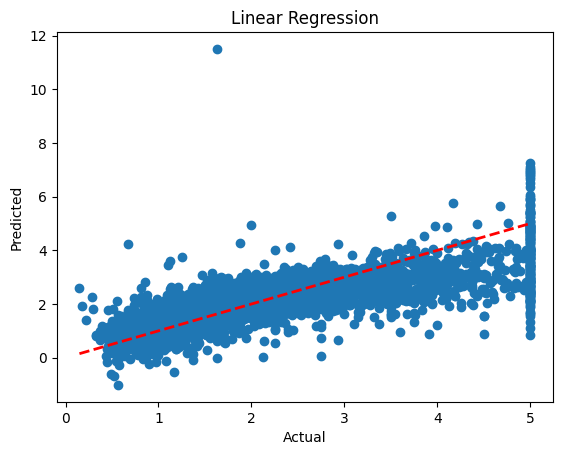

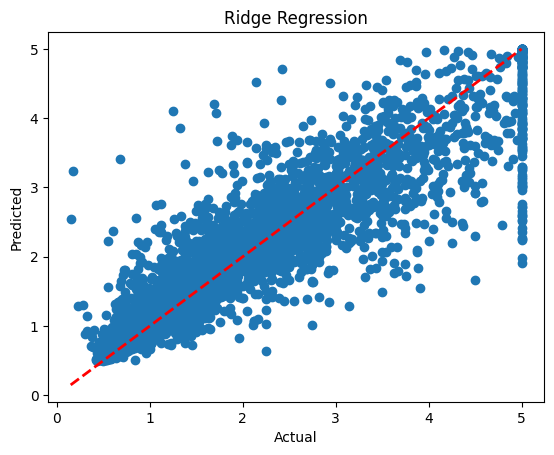

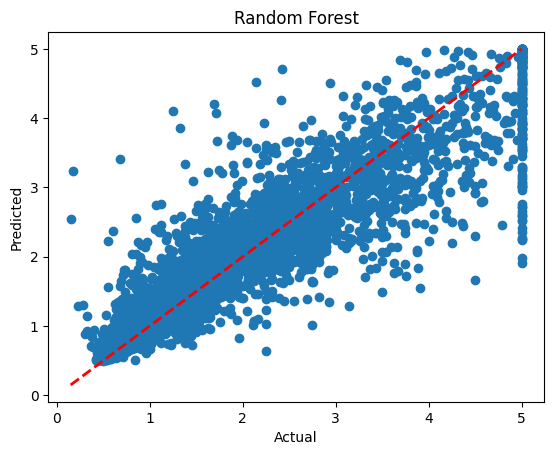

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# 1.Провести попередній аналіз даних за схемою (дивиться вище).
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["target"] = housing.target

print("Перші 5 рядків:")
print(df.head())

# 2.Масштабувати ознаки.
df.info()
df.describe()
df.isnull().sum()

# 3.Поділити дані на тренувальні і тестові.
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 4.Побудувати 3 моделі: лін. Регресія, регресія випадковий ліс, Ridge. Підібрати оптимальні параметри за допомогою GridSeach.
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

ridge = Ridge()
ridge_params = {"alpha": [0.1, 1, 10]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=3, scoring="r2")
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 5.Вивести R^2 і MSE. Побудувати графіки.
print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))

print("\nRidge (best params =", ridge_grid.best_params_, ")")
print("R2:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))

print("\nRandom Forest")
print("Parameters: n_estimators=100, max_depth=15")
print("R2:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

# 6.Вивести справжні і прогнозовані значення.
plt.figure()
plt.scatter(y_test, y_pred_lin)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    linestyle="--",
    zorder=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred_rf)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    linestyle="--",
    zorder=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred_rf, zorder=1)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    linestyle="--",
    zorder=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest")
plt.show()


Висновок:
У ході роботи було проведено аналіз датасету California Housing та побудовано три моделі регресії: лінійну регресію, Ridge та Random Forest.
Було виконано масштабування ознак, що є важливим для моделей з регуляризацією.

За результатами оцінки якості моделей (R² та MSE) встановлено, що:

1)Лінійна регресія показує базовий рівень точності.

2)Ridge дозволяє покращити узагальнення моделі за рахунок регуляризації.

3)Random Forest демонструє найкращу якість прогнозування завдяки здатності враховувати нелінійні залежності між ознаками.